# `macTrunCore` — Python Golden Model

Bit-accurate, cycle-accurate Python simulation of the active `mac_truncate` SystemVerilog module (`mac_truncate.sv`).

---

## Module Architecture (`MAC_LATENCY = 2`)

```
Inputs: p00..p22  (8-bit unsigned)   k0..k8  (9-bit signed)   valid_in
                         │
                ┌────────▼────────┐
   posedge clk  │   STAGE 1       │  always_ff
                │  Register all   │  p00_r..p22_r   (8-bit)
                │  inputs         │  k0_r..k8_r     (9-bit signed)
                │                 │  valid_s1 ← valid_in
                └────────┬────────┘
                         │ (combinational)
                ┌────────▼────────┐
                │  9 × MULTIPLY   │  s1_prod[i]  18-bit signed
                │  p00_r × k8_r   │  ← 180° kernel rotation
                │  p01_r × k7_r   │  (convolution, not correlation)
                │  ...            │
                │  p22_r × k0_r   │
                └────────┬────────┘
                         │ sign-extend 18→21 bit  (pe[0..8])
                ┌────────▼────────┐
                │  ADDER TREE     │  s2_sumA = pe[0]+pe[1]+pe[2]+pe[3]  (21-bit)
                │  (combinational)│  s2_sumB = pe[4]+pe[5]+pe[6]+pe[7]+pe[8]
                └────────┬────────┘
                         │ sign-extend 21→22 bit  (sA_ext, sB_ext)
                ┌────────▼────────┐
                │  acc = sA+sB    │  22-bit signed  (combinational)
                └────────┬────────┘
                         │
                ┌────────▼────────┐
   posedge clk  │   STAGE 2       │  always_ff
                │  Saturating     │  acc[21]=1      → result = 0
                │  Clamp          │  |acc[20:8]≠0   → result = 255
                │                 │  else           → result = acc[7:0]
                │                 │  valid_s2 ← valid_s1
                └────────┬────────┘
                         │
              valid_out = valid_s2      result [7:0]
```

### Key Architectural Notes

**180° Kernel Rotation** — This module computes mathematical **convolution** (not cross-correlation). The pixel-to-kernel pairings are spatially flipped:
```
  p00×k8  p01×k7  p02×k6        (top row paired with bottom row of kernel)
  p10×k5  p11×k4  p12×k3        (middle paired with middle, reversed)
  p20×k2  p21×k1  p22×k0        (bottom row paired with top row of kernel)
```
For symmetric kernels (Gaussian, Laplacian) the output is identical to cross-correlation. For asymmetric kernels (Sobel), the gradient polarity is inverted — the saturating clamp to [0,255] means only one polarity survives.

**2-Stage vs 3-Stage** — The commented-out design (MAC_LATENCY=3) registered the products in Stage 1. This active design registers the *inputs* in Stage 1 and computes all multiplications and additions combinationally, then registers only the final clamped result. This trades a deeper adder tree for lower pipeline latency.

**18-bit Product Width** — `$signed({1'b0, pixel})` × `kernel_9bit` = 9×9 signed = 18-bit result (range: −65280 to +65025). Stored in `s1_prod [17:0]`.

---
### Bit-Width Summary
| Signal | SV Type | Range | Python mask |
|---|---|---|---|
| `p00..p22` | `logic [7:0]` | 0–255 | `& 0xFF` |
| `k0..k8` | `logic signed [8:0]` | −256–255 | `to_signed(v, 9)` |
| `p_r, k_r` | same as inputs | same | same |
| `s1_prod` | `signed [17:0]` | −65280–65025 | `to_signed(v, 18)` |
| `pe` | `signed [20:0]` | sign-ext of above | `to_signed(v, 21)` |
| `s2_sumA/B` | `signed [20:0]` | sum of 4 or 5 pe | `to_signed(v, 21)` |
| `acc` | `signed [21:0]` | −2097152–2097151 | `to_signed(v, 22)` |
| `result` | `logic [7:0]` | 0–255 | `& 0xFF` |

In [2]:
import time
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Optional
from PIL import Image
import os

print("Imports complete")

Imports complete


---
## 1 — Bit-Width Utility Functions

Every arithmetic operation in the model uses these helpers to enforce the exact same bit widths as the SystemVerilog. This ensures overflow, wrap-around, and sign-extension all behave identically to hardware.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Bit-width utilities — mirror SV fixed-width signed/unsigned arithmetic
# ─────────────────────────────────────────────────────────────────────────────

def to_signed(value: int, bits: int) -> int:
    """
    Mask `value` to `bits` wide and interpret as two's-complement signed.
    Equivalent to assigning an arbitrary Python int to `logic signed [bits-1:0]`.

    Examples:
      to_signed(255, 8)  →  -1   (0xFF as 8-bit signed)
      to_signed(128, 8)  → -128  (0x80 as 8-bit signed)
      to_signed(127, 8)  →  127  (fits positive)
      to_signed(-1, 9)   → -1    (0x1FF as 9-bit signed)
    """
    mask = (1 << bits) - 1
    value = value & mask                    # keep only `bits` LSBs
    if value >= (1 << (bits - 1)):          # MSB set → negative in two's complement
        value -= (1 << bits)
    return value


def to_unsigned(value: int, bits: int) -> int:
    """Mask `value` to `bits` wide and interpret as unsigned."""
    return value & ((1 << bits) - 1)


def sign_extend(value: int, from_bits: int, to_bits: int) -> int:
    """
    Sign-extend a `from_bits`-wide signed value to `to_bits` wide.
    Mirrors SV: `logic signed [to_bits-1:0] x = narrow_signed_wire`

    In SV, assigning a narrower signed type to a wider signed type
    automatically sign-extends (LRM §10.7).
    """
    v = to_signed(value, from_bits)         # ensure it's the right signed value
    return to_signed(v, to_bits)            # fit into wider type (sign-extends)


def bit_range(value: int, hi: int, lo: int) -> int:
    """
    Extract bits [hi:lo] from value, as an unsigned integer.
    Mirrors SV `value[hi:lo]`.
    """
    return (value >> lo) & ((1 << (hi - lo + 1)) - 1)


def reduction_or(value: int, hi: int, lo: int) -> bool:
    """
    Reduction OR of bits [hi:lo]: returns True if any bit is set.
    Mirrors SV `|value[hi:lo]`.
    """
    return bit_range(value, hi, lo) != 0


# ── Quick self-tests ──────────────────────────────────────────────────────────
assert to_signed(0xFF, 8) == -1
assert to_signed(0x80, 8) == -128
assert to_signed(0x7F, 8) == 127
assert to_signed(-1, 9)   == -1          # 9-bit two's complement of -1 = 0x1FF → -1
assert to_signed(-256, 9) == -256        # min 9-bit signed
assert to_signed(255, 9)  == 255         # max 9-bit signed
assert sign_extend(0xFF, 8, 16) == -1    # sign-extend -1 from 8 to 16 bits
assert sign_extend(0x7F, 8, 16) == 127   # positive, no change
assert bit_range(0b11001, 4, 2) == 0b110 # bits [4:2] = 110
assert reduction_or(0b10110, 4, 1) == True
assert reduction_or(0b00001, 4, 1) == False
print("All bit-utility self-tests passed ✓")

All bit-utility self-tests passed ✓


---
## 2 — `MacTruncate` Golden Model Class

A complete cycle-accurate replica of the active `mac_truncate` SystemVerilog module. Every register, every combinational signal, and every clock edge is explicitly modelled.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# MacTruncate — Python Golden Model
# Mirrors macTrunCore.sv exactly, including all intermediate signal names.
# ─────────────────────────────────────────────────────────────────────────────

class MacTruncate:
    """
    Cycle-accurate Python model of mac_truncate (MAC_LATENCY=2).

    Port map (identical to SV):
      Inputs:  p00..p22  uint8  [7:0]     — 3×3 pixel window
               k0..k8   int9   [8:0]     — kernel coefficients (signed)
               valid_in  bool             — window + kernel are stable
               arstn     bool             — active-low async reset
      Outputs: valid_out bool             — result valid (MAC_LATENCY cycles later)
               result    uint8  [7:0]     — saturating-clamped output

    Usage:
      mac = MacTruncate()
      mac.arstn = True
      mac.set_pixels([p00,p01,...,p22])    # 9-element list, row-major
      mac.set_kernel([k0,k1,...,k8])
      mac.valid_in = True
      mac.clock()                          # posedge 1
      mac.valid_in = False
      mac.clock()                          # posedge 2
      print(mac.result, mac.valid_out)     # result ready here
    """

    MAC_LATENCY = 2   # matches parameter in SV module

    def __init__(self):
        # ── Inputs (driven externally before each clock()) ────────────────
        self.p   = [0] * 9      # p00..p22 flat [row-major]
        self.k   = [0] * 9      # k0..k8
        self.valid_in = False
        self.arstn    = False   # start in reset

        # ── Stage 1 registers (always_ff block 1) ─────────────────────────
        # SV: p00_r..p22_r  logic [7:0]
        #     k0_r..k8_r    logic signed [8:0]
        #     valid_s1      logic
        self.p_r      = [0] * 9   # registered pixel window
        self.k_r      = [0] * 9   # registered kernel coefficients
        self.valid_s1 = False

        # ── Stage 2 registers (always_ff block 2) ─────────────────────────
        # SV: result   logic [7:0]
        #     valid_s2 logic
        self.result   = 0
        self.valid_s2 = False

        # ── Internal cycle counter ─────────────────────────────────────────
        self.cycle = 0

    # ── Public interface ──────────────────────────────────────────────────────

    @property
    def valid_out(self) -> bool:
        """SV: assign valid_out = valid_s2"""
        return self.valid_s2

    def set_pixels(self, pixels: list):
        """Drive 9 pixel inputs. Order: [p00,p01,p02, p10,p11,p12, p20,p21,p22]"""
        assert len(pixels) == 9, "Need exactly 9 pixel values"
        self.p = [int(v) & 0xFF for v in pixels]

    def set_kernel(self, kernel: list):
        """Drive 9 kernel inputs. Order: [k0,k1,k2, k3,k4,k5, k6,k7,k8]"""
        assert len(kernel) == 9, "Need exactly 9 kernel values"
        self.k = [to_signed(int(v), 9) for v in kernel]

    def reset(self):
        """Assert arstn=False then apply one clock edge — clears all state."""
        self.arstn = False
        self.clock()

    def clock(self):
        """
        Advance one positive clock edge.

        Implements the simultaneous update rule of synthesised flip-flops:
          All 'next' values are computed from the pre-edge state, then
          all registers are updated at once.

        Signal update order (matching SV always_ff evaluation):
          1. If !arstn: all registers → 0, return.
          2. Combinational signals (acc) are computed from CURRENT p_r, k_r.
          3. Stage 1 registers capture current inputs: p_r←p, k_r←k, valid_s1←valid_in
          4. Stage 2 registers capture combinational: result←clamp(acc), valid_s2←valid_s1
        """
        self.cycle += 1

        if not self.arstn:
            # always_ff: if (!arstn) — reset all to zero
            self.p_r      = [0] * 9
            self.k_r      = [0] * 9
            self.valid_s1 = False
            self.result   = 0
            self.valid_s2 = False
            return

        # ── Combinational logic (from CURRENT registered state) ───────────
        # This is what the hardware sees just before the clock edge.
        # Uses self.p_r and self.k_r (not yet updated).
        acc = self._combinational_acc(self.p_r, self.k_r)

        # ── Compute next-state values ─────────────────────────────────────
        # Stage 1 next:  p_r ← p,  k_r ← k,  valid_s1 ← valid_in
        next_p_r      = [v & 0xFF for v in self.p]     # 8-bit unsigned
        next_k_r      = [to_signed(v, 9) for v in self.k]  # 9-bit signed
        next_valid_s1 = bool(self.valid_in)

        # Stage 2 next:  result ← clamp(acc),  valid_s2 ← valid_s1
        next_result   = self._clamp(acc)
        next_valid_s2 = bool(self.valid_s1)

        # ── Commit all registers simultaneously ───────────────────────────
        self.p_r      = next_p_r
        self.k_r      = next_k_r
        self.valid_s1 = next_valid_s1
        self.result   = next_result
        self.valid_s2 = next_valid_s2

    # ── Internal combinational logic ──────────────────────────────────────────

    def _combinational_acc(self, p_r: list, k_r: list) -> int:
        """
        Compute acc combinationally from registered p_r and k_r.
        This is the entire always_comb section of the SV module:
          s1_prod → pe → s2_sumA/B → sA_ext/sB_ext → acc

        Kernel pairing (180° rotation — convolution not correlation):
          s1_prod[0] = p00_r × k8_r      s1_prod[3] = p10_r × k5_r
          s1_prod[1] = p01_r × k7_r      s1_prod[4] = p11_r × k4_r
          s1_prod[2] = p02_r × k6_r      s1_prod[5] = p12_r × k3_r
          s1_prod[6] = p20_r × k2_r
          s1_prod[7] = p21_r × k1_r
          s1_prod[8] = p22_r × k0_r
        """
        # ── Pixel–kernel pairing (180° rotation from SV) ──────────────────
        # SV: $signed({1'b0, p_r}) — zero-pad 8-bit pixel to 9-bit non-negative signed
        # then multiply by 9-bit signed kernel → 18-bit signed result
        kernel_indices = [8, 7, 6, 5, 4, 3, 2, 1, 0]  # k paired with each pixel

        s1_prod = []
        for i in range(9):
            px9  = p_r[i] & 0xFF          # {1'b0, p_r[i]} — 9-bit, MSB=0, non-negative
            kn9  = to_signed(k_r[kernel_indices[i]], 9)  # 9-bit signed kernel
            prod = px9 * kn9              # Python int product (no overflow)
            s1_prod.append(to_signed(prod, 18))  # truncate to 18-bit signed

        # ── Sign-extension 18 → 21 bits (SV: pe[i] = s1_prod[i]) ─────────
        pe = [sign_extend(v, 18, 21) for v in s1_prod]

        # ── Partial-sum adder tree (SV: always_comb, 21-bit) ─────────────
        s2_sumA = to_signed(pe[0] + pe[1] + pe[2] + pe[3], 21)
        s2_sumB = to_signed(pe[4] + pe[5] + pe[6] + pe[7] + pe[8], 21)

        # ── Final accumulation (SV: acc = sA_ext + sB_ext, 22-bit) ───────
        sA_ext = sign_extend(s2_sumA, 21, 22)
        sB_ext = sign_extend(s2_sumB, 21, 22)
        acc    = to_signed(sA_ext + sB_ext, 22)
        return acc

    def _clamp(self, acc: int) -> int:
        """
        Saturating clamp — mirrors the always_ff block in SV Stage 2:
          if (acc[21])        result <= 8'd0;    // negative
          else if (|acc[20:8]) result <= 8'd255; // above byte range
          else                result <= acc[7:0];

        acc is a 22-bit signed value (already processed by to_signed(v, 22)).
        acc[21] is the sign bit — equivalent to acc < 0.
        |acc[20:8]: reduction OR of bits 20 down to 8 — any set bit means acc > 255.
        """
        # acc[21] — sign bit of 22-bit two's complement = acc < 0
        if acc < 0:
            return 0
        # |acc[20:8] — bits [20:8] include any value > 255 when acc >= 0
        # acc & 0x3FFFFF gives the 22-bit unsigned representation
        acc_u22 = acc & 0x3FFFFF
        if reduction_or(acc_u22, 20, 8):   # any bit above the byte range
            return 255
        return acc_u22 & 0xFF              # acc[7:0]

    # ── Helper: capture all internal signals for waveform display ─────────────

    def capture_signals(self) -> dict:
        """
        Return a snapshot of all signals at the current post-edge state.
        Useful for waveform tracing.
        """
        acc = self._combinational_acc(self.p_r, self.k_r)
        return {
            'cycle'    : self.cycle,
            'p_r'      : list(self.p_r),
            'k_r'      : list(self.k_r),
            'valid_s1' : int(self.valid_s1),
            'acc'      : acc,
            'result'   : self.result,
            'valid_s2' : int(self.valid_s2),
            'valid_out': int(self.valid_out),
        }

    # ── Convenience: run full image convolution ───────────────────────────────

    def convolve_image(self, img: np.ndarray, kernel: np.ndarray) -> tuple:
        """
        Run the full cycle-accurate pipeline over a 2-D grayscale image.

        Slides the 3×3 window column by column, row by row (left→right, top→bottom),
        skipping the border pixels (matching the hardware line_buffer col_idx logic).

        Returns:
          output   np.ndarray  uint8  shape (H-2, W-2) — valid output pixels
          stats    dict        timing, cycle counts, throughput
        """
        assert img.ndim == 2, "Expected 2-D grayscale image"
        H, W = img.shape
        k_flat = kernel.flatten().tolist()

        self.arstn = True
        self.set_kernel(k_flat)

        output    = np.zeros((H - 2, W - 2), dtype=np.uint8)
        waveforms = []
        cycle_start = self.cycle
        t0 = time.perf_counter()

        # Pipeline fill: drive first window, assert valid_in
        for row in range(1, H - 1):
            for col in range(1, W - 1):
                window = [
                    img[row-1, col-1], img[row-1, col], img[row-1, col+1],
                    img[row,   col-1], img[row,   col], img[row,   col+1],
                    img[row+1, col-1], img[row+1, col], img[row+1, col+1],
                ]
                self.set_pixels(window)
                self.valid_in = True
                self.clock()
                waveforms.append(self.capture_signals())

        # Pipeline drain: one extra cycle to flush last result
        self.valid_in = False
        self.clock()
        waveforms.append(self.capture_signals())

        t1 = time.perf_counter()
        total_cycles  = self.cycle - cycle_start
        elapsed_s     = t1 - t0

        # Collect results: valid_out is high starting at cycle where result is ready.
        # Because MAC_LATENCY=2: result[col] is valid on the cycle AFTER we drove col.
        # We read results from waveforms where valid_out==1.
        result_flat = [w['result'] for w in waveforms if w['valid_out']]
        if len(result_flat) == (H - 2) * (W - 2):
            output = np.array(result_flat, dtype=np.uint8).reshape(H - 2, W - 2)

        stats = {
            'total_cycles'     : total_cycles,
            'valid_pixels'     : (H - 2) * (W - 2),
            'elapsed_s'        : elapsed_s,
            'elapsed_us'       : elapsed_s * 1e6,
            'cycles_per_pixel' : total_cycles / ((H - 2) * (W - 2)),
            'throughput_mpps'  : ((H - 2) * (W - 2)) / elapsed_s / 1e6,
            'waveforms'        : waveforms,
        }
        return output, stats


print("MacTruncate class defined ✓")
print(f"  MAC_LATENCY = {MacTruncate.MAC_LATENCY}")
print(f"  Pipeline stages: 2 (input register → combinational → clamp register)")

MacTruncate class defined ✓
  MAC_LATENCY = 2
  Pipeline stages: 2 (input register → combinational → clamp register)


---
## 3 — Verification: Single-Cycle Tests

Each test mirrors a typical RTL testbench stimulus. The expected value is computed independently using a pure arithmetic reference function, then compared against the model output.

In [5]:
# ── Independent reference function (no pipeline, pure arithmetic) ─────────────
# Used to compute expected values for each test case.
# Replicates the SV combinational logic directly.

def reference_mac(pixels: list, kernel: list) -> int:
    """
    Compute the expected clamped result for a single 3×3 window.
    Applies the same 180° kernel rotation as the SV module:
      p[i] * k[8-i]  for i in 0..8
    """
    kernel_rot = [8, 7, 6, 5, 4, 3, 2, 1, 0]   # SV pairs pixel i with kernel[8-i]
    acc = 0
    for i in range(9):
        px9  = int(pixels[i]) & 0xFF
        kn9  = to_signed(int(kernel[kernel_rot[i]]), 9)
        prod = to_signed(px9 * kn9, 18)
        pe   = sign_extend(prod, 18, 21)
        acc += pe
    acc = to_signed(acc, 22)
    if acc < 0:
        return 0
    if reduction_or(acc & 0x3FFFFF, 20, 8):
        return 255
    return acc & 0xFF


# ── Test runner ────────────────────────────────────────────────────────────────
def run_test(label, pixels, kernel, expected, mac=None):
    if mac is None:
        mac = MacTruncate()
    mac.arstn = False; mac.clock()   # reset
    mac.arstn = True
    mac.set_pixels(pixels)
    mac.set_kernel(kernel)
    mac.valid_in = True
    mac.clock()                      # posedge 1 — inputs registered
    mac.valid_in = False
    mac.clock()                      # posedge 2 — result latched, valid_out=1

    ok = (mac.result == expected) and mac.valid_out
    status = "PASS ✓" if ok else f"FAIL ✗  got={mac.result}"
    print(f"  {label:<45}  exp={expected:>3}  {status}")
    return ok


print("Running verification tests...\n")
all_pass = True

# ─── T1: Identity kernel — centre pixel passes through ────────────────────────
# k4=1, all others=0 → result = p11
# With 180° rotation: p11 * k4 = 128 * 1 = 128 (centre always pairs with centre)
p_t1 = [0]*4 + [128] + [0]*4
k_id = [0,0,0, 0,1,0, 0,0,0]
all_pass &= run_test("T1  Identity kernel (k4=1, p11=128)", p_t1, k_id,
                     reference_mac(p_t1, k_id))

# ─── T2: All-ones kernel, all pixels = 100 → 9×100 = 900 → clamp 255 ───────
p_t2 = [100]*9
k_t2 = [1]*9
all_pass &= run_test("T2  All-ones kernel, px=100 → 900 → clamp 255", p_t2, k_t2,
                     reference_mac(p_t2, k_t2))

# ─── T3: Sum exactly 255 — no clamp ──────────────────────────────────────────
# p00=255, k0=1, rest=0  →  p00*k8=0 ... p22*k0=255*1=255 (rotation: p22 pairs k0)
p_t3 = [0]*8 + [255]
k_t3 = [1,0,0, 0,0,0, 0,0,0]
all_pass &= run_test("T3  Sum=255 exactly, no clamp", p_t3, k_t3,
                     reference_mac(p_t3, k_t3))

# ─── T4: Sum = 256 → clamp 255 ───────────────────────────────────────────────
p_t4 = [0]*8 + [256 % 256]   # p22=0, so find what gives 256
# p00=2, k8=128 → 2*128=256 → clamp (rotation: p00 pairs k8)
p_t4 = [2] + [0]*8
k_t4 = [0,0,0, 0,0,0, 0,0,128]
all_pass &= run_test("T4  Sum=256 → clamp 255", p_t4, k_t4,
                     reference_mac(p_t4, k_t4))

# ─── T5: All-negative kernel, all px=255 → large negative → clamp 0 ─────────
p_t5 = [255]*9
k_t5 = [-1]*9
all_pass &= run_test("T5  All-neg kernel, px=255 → clamp 0", p_t5, k_t5,
                     reference_mac(p_t5, k_t5))

# ─── T6: Zero kernel → result = 0 ────────────────────────────────────────────
p_t6 = [200]*9
k_t6 = [0]*9
all_pass &= run_test("T6  Zero kernel → result=0", p_t6, k_t6,
                     reference_mac(p_t6, k_t6))

# ─── T7: Zero pixels → result = 0 ────────────────────────────────────────────
p_t7 = [0]*9
k_t7 = [127]*9
all_pass &= run_test("T7  Zero pixels → result=0", p_t7, k_t7,
                     reference_mac(p_t7, k_t7))

# ─── T8: Maximum positive (no overflow in 22-bit) ────────────────────────────
# 9 × 255 × 255 = 585225 > 22-bit max (2097151), but per-product max 255×255=65025 < 2^18
# Sum = 9×65025 = 585225 → bits[20:8] non-zero → clamp 255
p_t8 = [255]*9
k_t8 = [255]*9
all_pass &= run_test("T8  px=255, k=255 → max positive overflow", p_t8, k_t8,
                     reference_mac(p_t8, k_t8))

# ─── T9: Sobel horizontal kernel on uniform image → 0 (no edges) ─────────────
p_t9 = [128]*9   # uniform patch
k_sobel = [-1,0,1, -2,0,2, -1,0,1]
all_pass &= run_test("T9  Sobel on uniform 128 → 0 (no edge)", p_t9, k_sobel,
                     reference_mac(p_t9, k_sobel))

# ─── T10: Sobel on sharp vertical edge ───────────────────────────────────────
p_t10 = [0,0,255, 0,0,255, 0,0,255]  # right half bright
all_pass &= run_test("T10 Sobel on vertical edge (180° rotation check)",
                     p_t10, k_sobel, reference_mac(p_t10, k_sobel))

print(f"\n{'All tests PASSED ✓' if all_pass else 'Some tests FAILED ✗'}")

Running verification tests...

  T1  Identity kernel (k4=1, p11=128)            exp=128  PASS ✓
  T2  All-ones kernel, px=100 → 900 → clamp 255  exp=255  PASS ✓
  T3  Sum=255 exactly, no clamp                  exp=255  PASS ✓
  T4  Sum=256 → clamp 255                        exp=255  PASS ✓
  T5  All-neg kernel, px=255 → clamp 0           exp=  0  PASS ✓
  T6  Zero kernel → result=0                     exp=  0  PASS ✓
  T7  Zero pixels → result=0                     exp=  0  PASS ✓
  T8  px=255, k=255 → max positive overflow      exp=255  PASS ✓
  T9  Sobel on uniform 128 → 0 (no edge)         exp=  0  PASS ✓
  T10 Sobel on vertical edge (180° rotation check)  exp=  0  PASS ✓

All tests PASSED ✓


---
## 4 — Pipeline Timing Verification

Verify that `valid_out` asserts exactly `MAC_LATENCY = 2` clock edges after `valid_in`, and that back-to-back throughput is 1 result/cycle once the pipeline is full.

In [6]:
# ── Timing test: valid_in → valid_out delay = MAC_LATENCY ─────────────────────
mac = MacTruncate()
mac.arstn = False; mac.clock()
mac.arstn = True

k_id = [0,0,0, 0,1,0, 0,0,0]       # identity kernel
mac.set_kernel(k_id)

timing_log = []

for cyc in range(6):
    if cyc == 0:
        mac.set_pixels([0]*4 + [200] + [0]*4)
        mac.valid_in = True
    else:
        mac.valid_in = False
    mac.clock()
    timing_log.append({
        'cycle'    : cyc + 1,
        'valid_in' : 1 if cyc == 0 else 0,
        'valid_s1' : int(mac.valid_s1),
        'valid_s2' : int(mac.valid_s2),
        'valid_out': int(mac.valid_out),
        'result'   : mac.result,
    })

print("Pipeline timing trace (identity kernel, p11=200)")
print(f"{'Cycle':>6}  {'valid_in':>8}  {'valid_s1':>8}  {'valid_s2':>8}  {'valid_out':>9}  {'result':>6}  note")
print("─" * 70)
for r in timing_log:
    note = ""
    if r['valid_in']:  note = "← valid_in asserted"
    if r['valid_out']: note = "← result READY (MAC_LATENCY=2 ✓)"
    print(f"  {r['cycle']:>4}  {r['valid_in']:>8}  {r['valid_s1']:>8}  "
          f"{r['valid_s2']:>8}  {r['valid_out']:>9}  {r['result']:>6}  {note}")

assert timing_log[1]['valid_out'] == 1, "Expected valid_out at cycle 2!"
assert timing_log[1]['result'] == 200,  "Expected result=200 (identity) at cycle 2!"
print("\nMAC_LATENCY=2 timing confirmed ✓")

Pipeline timing trace (identity kernel, p11=200)
 Cycle  valid_in  valid_s1  valid_s2  valid_out  result  note
──────────────────────────────────────────────────────────────────────
     1         1         1         0          0       0  ← valid_in asserted
     2         0         0         1          1     200  ← result READY (MAC_LATENCY=2 ✓)
     3         0         0         0          0     200  
     4         0         0         0          0     200  
     5         0         0         0          0     200  
     6         0         0         0          0     200  

MAC_LATENCY=2 timing confirmed ✓


In [7]:
# ── Back-to-back throughput: 1 result per cycle ───────────────────────────────
# Send 4 different windows consecutively, expect 4 results at cycles 2,3,4,5

mac = MacTruncate()
mac.arstn = False; mac.clock()
mac.arstn = True

k_id = [0,0,0, 0,1,0, 0,0,0]  # identity: result = p11
mac.set_kernel(k_id)

inputs_p11 = [10, 50, 150, 240]   # four different centre pixels
dispatch_log = []

# Dispatch all 4 windows
for i, p11 in enumerate(inputs_p11):
    mac.set_pixels([0]*4 + [p11] + [0]*4)
    mac.valid_in = True
    mac.clock()
    dispatch_log.append(mac.capture_signals())

# Pipeline drain (2 extra cycles for MAC_LATENCY=2)
for _ in range(MacTruncate.MAC_LATENCY):
    mac.valid_in = False
    mac.clock()
    dispatch_log.append(mac.capture_signals())

print("Back-to-back throughput test (identity kernel, 4 windows)")
print(f"{'Cycle':>6}  {'valid_out':>9}  {'result':>6}  {'expected':>8}")
print("─" * 40)
expected_out = inputs_p11  # identity kernel → result = p11
result_idx   = 0
for r in dispatch_log:
    exp_str = ""
    if r['valid_out']:
        exp = expected_out[result_idx] if result_idx < len(expected_out) else '-'
        exp_str = str(exp)
        chk = "✓" if r['result'] == exp else f"✗ (got {r['result']})"
        print(f"  {r['cycle']:>4}  {r['valid_out']:>9}  {r['result']:>6}  {exp_str:>8}  {chk}")
        result_idx += 1
    else:
        print(f"  {r['cycle']:>4}  {r['valid_out']:>9}  {r['result']:>6}  {'—':>8}")

print(f"\n{result_idx} results collected, {len(expected_out)} expected — "
      f"{'throughput OK ✓' if result_idx == len(expected_out) else 'throughput FAIL ✗'}")

Back-to-back throughput test (identity kernel, 4 windows)
 Cycle  valid_out  result  expected
────────────────────────────────────────
     2          0       0         —
     3          1      10        10  ✓
     4          1      50        50  ✓
     5          1     150       150  ✓
     6          1     240       240  ✓
     7          0     240         —

4 results collected, 4 expected — throughput OK ✓


In [8]:
# ── Reset mid-pipeline test ───────────────────────────────────────────────────
# Assert arstn=0 after valid_in — pipeline should flush immediately

mac = MacTruncate()
mac.arstn = False; mac.clock()
mac.arstn = True
mac.set_pixels([255]*9)
mac.set_kernel([1]*9)
mac.valid_in = True
mac.clock()                  # posedge 1: inputs registered, valid_s1=1

# Assert reset BEFORE the second posedge
mac.arstn = False
mac.valid_in = False
mac.clock()                  # posedge 2: reset fires → all registers clear

assert mac.result   == 0,   f"Expected result=0 after reset, got {mac.result}"
assert mac.valid_out == False, "Expected valid_out=0 after reset"
assert mac.valid_s1  == False, "Expected valid_s1=0 after reset"
print("Reset mid-pipeline: all registers cleared ✓")

# Recovery: re-enable and run a clean transaction
mac.arstn = True
mac.set_pixels([0]*4 + [99] + [0]*4)
mac.set_kernel([0,0,0, 0,1,0, 0,0,0])
mac.valid_in = True
mac.clock()
mac.valid_in = False
mac.clock()
assert mac.result == 99 and mac.valid_out, "Recovery after reset failed!"
print("Recovery after reset: result=99, valid_out=1 ✓")

Reset mid-pipeline: all registers cleared ✓
Recovery after reset: result=99, valid_out=1 ✓


---
## 5 — Pipeline Signal Waveform

Visualise every internal signal over time for a 6-window sequence — equivalent to reading a simulation waveform in Vivado or ModelSim.

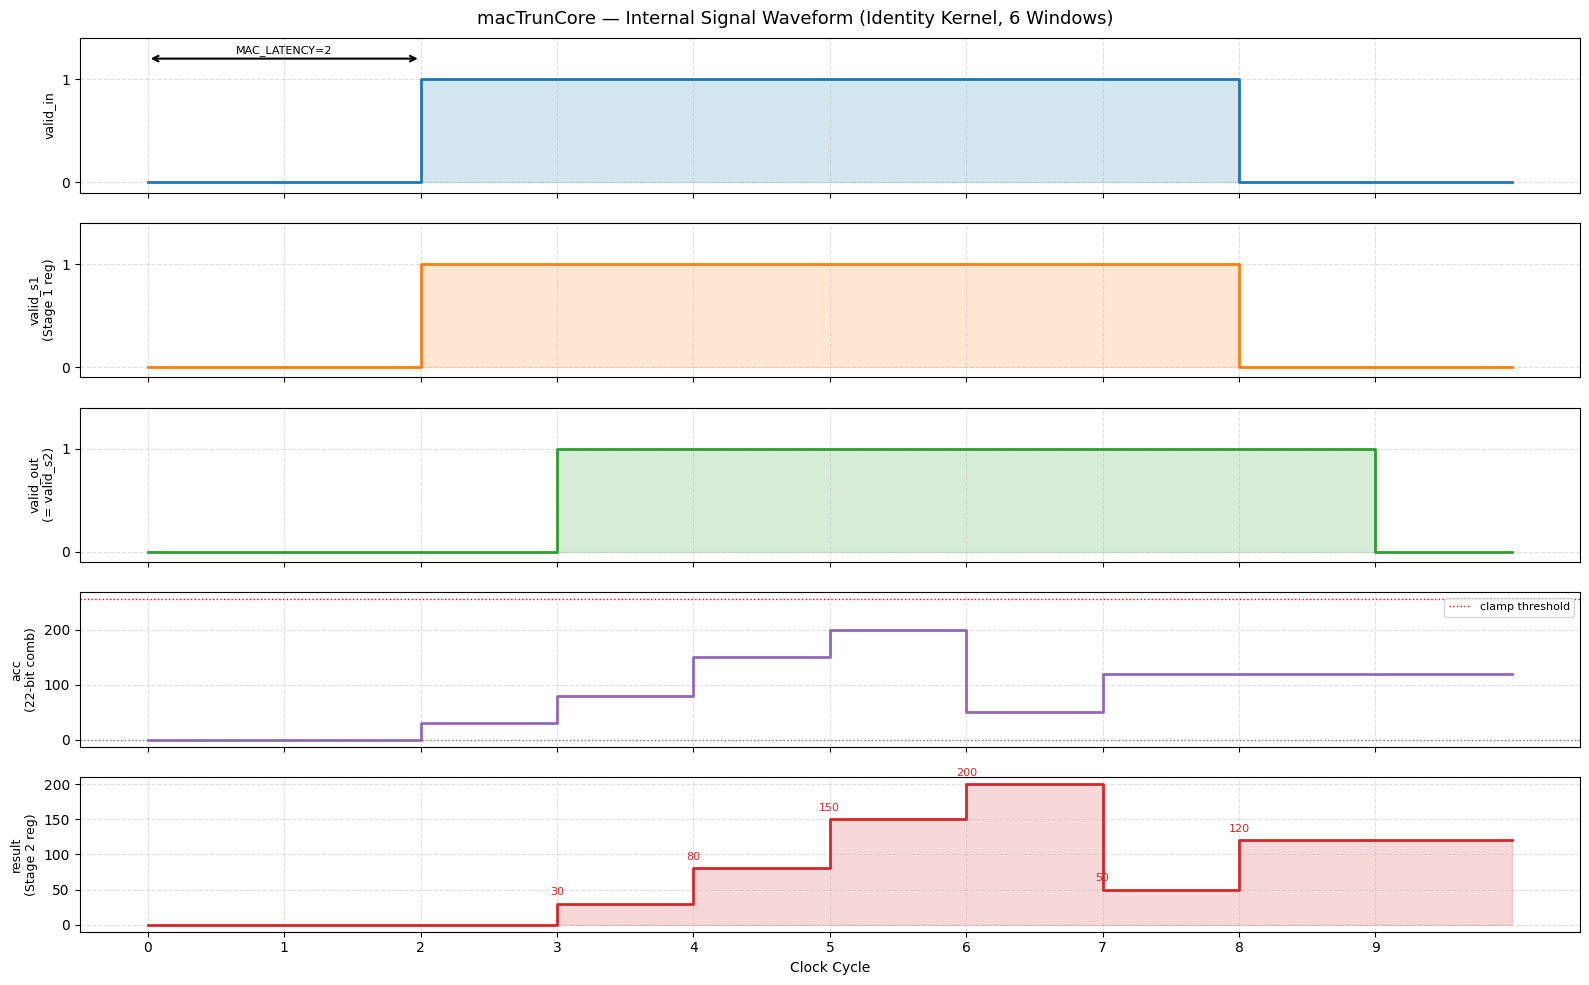

Saved: mac_truncate_waveform.png


In [9]:
# ── Collect waveform data for plotting ─────────────────────────────────────────
mac = MacTruncate()
mac.arstn = False; mac.clock()
mac.arstn = True

k_wave = [0,0,0, 0,1,0, 0,0,0]   # identity
mac.set_kernel(k_wave)

# 6 windows with distinct centre pixels: 30, 80, 150, 200, 50, 120
wave_inputs = [30, 80, 150, 200, 50, 120]
wave_log    = []

# Pre-edge snapshot (cycle 0)
wave_log.append({'cycle': 0, 'valid_in': 0, 'valid_s1': 0,
                 'valid_out': 0, 'result': 0, 'acc': 0})

for i, v in enumerate(wave_inputs):
    mac.set_pixels([0]*4 + [v] + [0]*4)
    mac.valid_in = True
    mac.clock()
    s = mac.capture_signals()
    s['valid_in_prev'] = 1   # what valid_in was before this edge
    wave_log.append(s)

for _ in range(MacTruncate.MAC_LATENCY + 1):
    mac.valid_in = False
    mac.clock()
    s = mac.capture_signals()
    s['valid_in_prev'] = 0
    wave_log.append(s)

# ── Plot waveform ─────────────────────────────────────────────────────────────
cycles  = [w['cycle']     for w in wave_log]
vin     = [w.get('valid_in_prev', 0) for w in wave_log]
vs1     = [w['valid_s1']  for w in wave_log]
vout    = [w['valid_out'] for w in wave_log]
results = [w['result']    for w in wave_log]
accs    = [w['acc']       for w in wave_log]

fig, axes = plt.subplots(5, 1, figsize=(16, 10), sharex=True)
fig.suptitle('macTrunCore — Internal Signal Waveform (Identity Kernel, 6 Windows)',
             fontsize=13)

def step_wave(ax, x, y, color, label, ylim=None):
    ax.step(x, y, where='post', color=color, linewidth=2)
    ax.fill_between(x, y, step='post', alpha=0.18, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.set_yticks([0, 1])
    ax.grid(True, linestyle='--', alpha=0.4)
    if ylim: ax.set_ylim(ylim)

step_wave(axes[0], cycles, vin,  '#1f77b4', 'valid_in',  ylim=(-0.1, 1.4))
step_wave(axes[1], cycles, vs1,  '#ff7f0e', 'valid_s1\n(Stage 1 reg)', ylim=(-0.1, 1.4))
step_wave(axes[2], cycles, vout, '#2ca02c', 'valid_out\n(= valid_s2)', ylim=(-0.1, 1.4))

axes[3].step(cycles, accs, where='post', color='#9467bd', linewidth=2)
axes[3].set_ylabel('acc\n(22-bit comb)', fontsize=9)
axes[3].axhline(0,   color='gray', linestyle=':', linewidth=1)
axes[3].axhline(255, color='red',  linestyle=':', linewidth=1, label='clamp threshold')
axes[3].grid(True, linestyle='--', alpha=0.4)
axes[3].legend(fontsize=8, loc='upper right')

axes[4].step(cycles, results, where='post', color='#d62728', linewidth=2)
axes[4].fill_between(cycles, results, step='post', alpha=0.18, color='#d62728')
axes[4].set_ylabel('result\n(Stage 2 reg)', fontsize=9)
axes[4].set_xlabel('Clock Cycle')
axes[4].grid(True, linestyle='--', alpha=0.4)
# Annotate expected values
for w in wave_log:
    if w['valid_out']:
        axes[4].annotate(str(w['result']), xy=(w['cycle'], w['result']),
                         xytext=(0, 6), textcoords='offset points',
                         ha='center', fontsize=8, color='#d62728')

# Mark MAC_LATENCY annotation
axes[0].annotate('', xy=(2, 1.2), xytext=(0, 1.2),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
axes[0].text(1, 1.25, 'MAC_LATENCY=2', ha='center', fontsize=8)

for ax in axes:
    ax.set_xticks(range(len(cycles)))

plt.tight_layout()
plt.savefig('mac_truncate_waveform.png', facecolor='white', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: mac_truncate_waveform.png")

---
## 6 — Image Convolution Demo

Run the full cycle-accurate model over a real image. Compares the model output against an independent NumPy reference to confirm bit-exact equivalence.

In [12]:
# ── Build a test image (works with or without testSet folder) ──────────────────
TEST_IMG_PATH = None
FOLDER = 'testSet'
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

if os.path.exists(FOLDER):
    candidates = [f for f in os.listdir(FOLDER) if f.lower().endswith(IMAGE_EXTENSIONS)]
    if candidates:
        TEST_IMG_PATH = os.path.join(FOLDER, candidates[0])

if TEST_IMG_PATH:
    test_img = np.array(Image.open(TEST_IMG_PATH).convert('L'), dtype=np.uint8)
    print(f"Using image: {TEST_IMG_PATH}  shape={test_img.shape}")
else:
    # Synthetic 28×28 test pattern with clear edges
    test_img = np.zeros((28, 28), dtype=np.uint8)
    test_img[:, 14:] = 200   # vertical edge at column 14
    test_img[7:21, 7:21] = 128  # inner rectangle
    print("testSet not found — using synthetic 28×28 test pattern")

# ── Kernels to test ────────────────────────────────────────────────────────────
kernels = {
    'Sobel H': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.int16),
    'Sobel V': np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=np.int16),
    'Laplacian': np.array([[0, 1, 0], [1,-4, 1], [0, 1, 0]], dtype=np.int16),
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.int16),
}

results_demo = {}
for kname, kmat in kernels.items():
    mac_demo = MacTruncate()
    out, stats = mac_demo.convolve_image(test_img, kmat)
    results_demo[kname] = (out, stats)
    print(f"  {kname:<12}  cycles={stats['total_cycles']}  "
          f"time={stats['elapsed_us']:.1f} µs  "
          f"throughput={stats['throughput_mpps']:.3f} Mpx/s")

testSet not found — using synthetic 28×28 test pattern
  Sobel H       cycles=677  time=11449.6 µs  throughput=0.059 Mpx/s
  Sobel V       cycles=677  time=12891.3 µs  throughput=0.052 Mpx/s
  Laplacian     cycles=677  time=12503.0 µs  throughput=0.054 Mpx/s
  Identity      cycles=677  time=8075.6 µs  throughput=0.084 Mpx/s


Verifying model output against reference_mac() for each kernel...

  Sobel H       PASS ✓
  Sobel V       PASS ✓
  Laplacian     PASS ✓
  Identity      PASS ✓


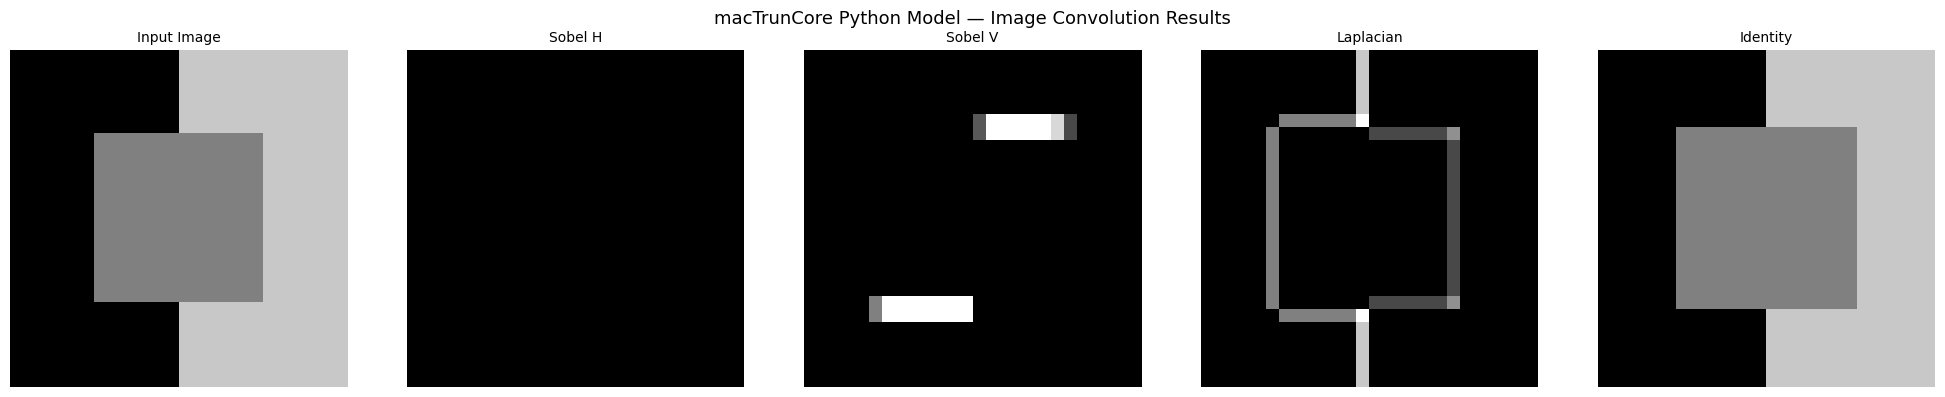

Saved: mac_model_convolution.png


In [13]:
# ── Bit-exact verification against NumPy reference ────────────────────────────
print("Verifying model output against reference_mac() for each kernel...\n")
H, W = test_img.shape

for kname, kmat in kernels.items():
    k_flat = kmat.flatten().tolist()
    ref_out = np.zeros((H-2, W-2), dtype=np.uint8)
    for r in range(1, H-1):
        for c in range(1, W-1):
            window = [
                int(test_img[r-1,c-1]), int(test_img[r-1,c]), int(test_img[r-1,c+1]),
                int(test_img[r,  c-1]), int(test_img[r,  c]), int(test_img[r,  c+1]),
                int(test_img[r+1,c-1]), int(test_img[r+1,c]), int(test_img[r+1,c+1]),
            ]
            ref_out[r-1, c-1] = reference_mac(window, k_flat)

    model_out = results_demo[kname][0]
    mismatches = int(np.sum(model_out != ref_out))
    status = "PASS ✓" if mismatches == 0 else f"FAIL ✗  ({mismatches} mismatches)"
    print(f"  {kname:<12}  {status}")

# ── Visualise results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(kernels) + 1, figsize=(20, 4))
fig.suptitle('macTrunCore Python Model — Image Convolution Results', fontsize=13)

axes[0].imshow(test_img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Input Image', fontsize=10)
axes[0].axis('off')

for ax, (kname, (out, _)) in zip(axes[1:], results_demo.items()):
    ax.imshow(out, cmap='gray', vmin=0, vmax=255)
    ax.set_title(kname, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('mac_model_convolution.png', facecolor='white', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: mac_model_convolution.png")

---
## 7 — Timing Benchmark

Measure the Python model's execution time per cycle and per image, then compare against:
- The **FPGA hardware** (theoretical, derived from MAC_LATENCY and clock frequency)
- The expected **Python model** overhead on this platform

The Python model is **not** meant to be fast — it is a correctness oracle and a timing reference. Its Python-side wall time sets the upper bound for the baseline comparison.

In [14]:
# ── Single-cycle timing ────────────────────────────────────────────────────────
N_WARMUP = 200
N_TRIALS = 5000

mac_bench = MacTruncate()
mac_bench.arstn = False; mac_bench.clock()
mac_bench.arstn = True
mac_bench.set_kernel([-1,0,1, -2,0,2, -1,0,1])   # Sobel
mac_bench.set_pixels([100,120,80, 140,200,90, 110,130,70])
mac_bench.valid_in = True

# Warmup
for _ in range(N_WARMUP):
    mac_bench.clock()

# Timed run
t0 = time.perf_counter()
for _ in range(N_TRIALS):
    mac_bench.clock()
t1 = time.perf_counter()

ns_per_cycle  = (t1 - t0) / N_TRIALS * 1e9
us_per_cycle  = ns_per_cycle / 1e3
cycles_per_s  = N_TRIALS / (t1 - t0)

print(f"Single clock() call performance ({N_TRIALS:,} trials):")
print(f"  Python model  : {ns_per_cycle:.1f} ns/cycle   ({cycles_per_s/1e6:.2f} Mcycles/s)")
print(f"  FPGA hardware : 10.0 ns/cycle  (100 MHz)")
print(f"  Slowdown      : {ns_per_cycle / 10.0:.0f}×")

Single clock() call performance (5,000 trials):
  Python model  : 9611.3 ns/cycle   (0.10 Mcycles/s)
  FPGA hardware : 10.0 ns/cycle  (100 MHz)
  Slowdown      : 961×


In [15]:
# ── Per-image timing benchmark ─────────────────────────────────────────────────
FPGA_CLK_HZ = 100e6
MAC_LATENCY = MacTruncate.MAC_LATENCY
IMG_H, IMG_W = 28, 28
VALID_PIXELS = (IMG_H - 2) * (IMG_W - 2)   # 676

N_IMAGES = 200   # images to time for stable average

# Build or load test images
if os.path.exists('testSet'):
    img_files = sorted([os.path.join('testSet', f)
                        for f in os.listdir('testSet')
                        if f.lower().endswith(IMAGE_EXTENSIONS)])[:N_IMAGES]
    test_images = [np.array(Image.open(p).convert('L'), dtype=np.uint8)
                   for p in img_files]
    print(f"Loaded {len(test_images)} images from testSet")
else:
    rng = np.random.default_rng(42)
    test_images = [rng.integers(0, 256, (IMG_H, IMG_W), dtype=np.uint8)
                   for _ in range(N_IMAGES)]
    print(f"Generated {N_IMAGES} synthetic {IMG_H}×{IMG_W} images")

k_sobel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.int16)

model_times = []
for img in test_images:
    mac_img = MacTruncate()
    _, s = mac_img.convolve_image(img, k_sobel)
    model_times.append(s['elapsed_s'])

model_avg_ms  = np.mean(model_times) * 1e3
model_throughput = len(test_images) / sum(model_times)

# Hardware theoretical timing
hw_compute_cycles = VALID_PIXELS + (MAC_LATENCY - 1)  # pipeline drain
hw_time_us        = hw_compute_cycles / FPGA_CLK_HZ * 1e6
hw_dma_overhead_us = 15.0   # PYNQ DMA typical
hw_practical_us   = hw_time_us + hw_dma_overhead_us

print(f"\n{'═'*60}")
print(f" TIMING COMPARISON — 28×28 image, Sobel kernel")
print(f"{'═'*60}")
print(f" {'Method':<35} {'Avg latency':>14}")
print(f"{'─'*60}")
print(f" {'Python golden model (cycle-accurate)':<35} {model_avg_ms*1e3:>11.1f} µs")
print(f" {'FPGA hardware — compute only':<35} {hw_time_us:>11.2f} µs")
print(f" {'FPGA hardware — with DMA (est.)':<35} {hw_practical_us:>11.2f} µs")
print(f"{'─'*60}")
print(f" {'Model vs HW compute speedup':<35} {model_avg_ms*1e3/hw_time_us:>10.0f}×  (HW faster)")
print(f" {'Model vs HW practical speedup':<35} {model_avg_ms*1e3/hw_practical_us:>10.0f}×  (HW faster)")
print(f"{'═'*60}")
print(f"\nNote: The Python model runs {model_avg_ms*1e3/hw_time_us:.0f}× slower than hardware.")
print(f"This is expected — the model simulates every flip-flop and wire in Python.")
print(f"Its value is correctness verification, not speed.")

Generated 200 synthetic 28×28 images

════════════════════════════════════════════════════════════
 TIMING COMPARISON — 28×28 image, Sobel kernel
════════════════════════════════════════════════════════════
 Method                                 Avg latency
────────────────────────────────────────────────────────────
 Python golden model (cycle-accurate)      8798.6 µs
 FPGA hardware — compute only               6.77 µs
 FPGA hardware — with DMA (est.)           21.77 µs
────────────────────────────────────────────────────────────
 Model vs HW compute speedup               1300×  (HW faster)
 Model vs HW practical speedup              404×  (HW faster)
════════════════════════════════════════════════════════════

Note: The Python model runs 1300× slower than hardware.
This is expected — the model simulates every flip-flop and wire in Python.
Its value is correctness verification, not speed.


---
## Full Summary

Side-by-side summary table: Python golden model vs FPGA hardware vs naive Python baseline.

Measuring naive Python baseline (50 images)...
  Naive Python avg: 0.51 ms/image


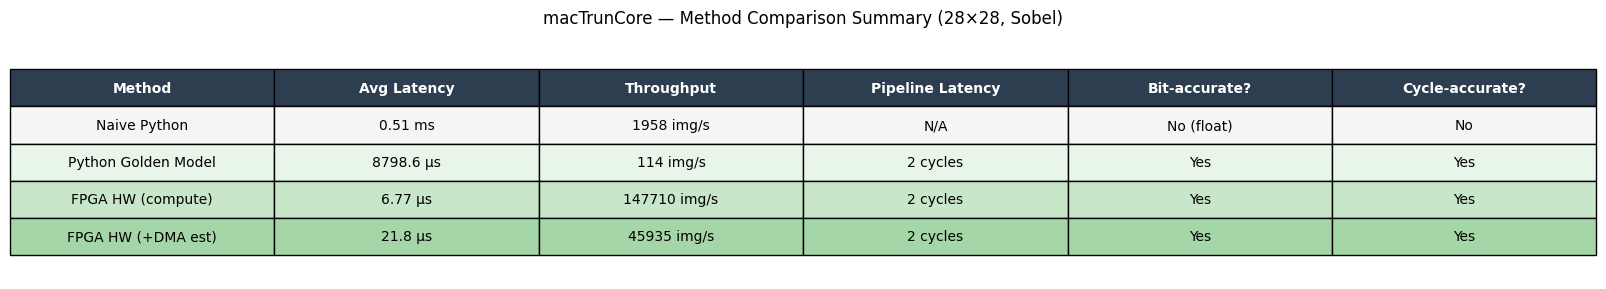

Saved: mac_summary_table.png

Speedup of FPGA compute over naive Python : 75×
Speedup of FPGA+DMA over naive Python     : 23×
Python golden model runs 1300× slower than HW (expected — simulating every FF and wire in interpreted Python)


In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
# Naive Python baseline estimate: from per-pixel timing in Section 7
# If you have run the hw_accelerator_benchmark.ipynb, import naive_avg_ms from there.
# Otherwise we estimate from raw Python loop timing.

def naive_loop_time_estimate(h=28, w=28, trials=50):
    """Measure time for a pure Python nested-loop convolution."""
    kern = [[-1,0,1],[-2,0,2],[-1,0,1]]
    img  = [[int(np.random.randint(0,256))] * w for _ in range(h)]
    def clamp(v): return 0 if v<0 else (255 if v>255 else v)
    def conv_once():
        px = [img[r][c] for r in range(h) for c in range(w)]
        for row in range(1, h-1):
            for col in range(1, w-1):
                acc = 0
                acc += px[(row-1)*w+(col-1)]*kern[0][0]; acc += px[(row-1)*w+col]*kern[0][1]
                acc += px[(row-1)*w+(col+1)]*kern[0][2]; acc += px[row*w+(col-1)]*kern[1][0]
                acc += px[row*w+col]*kern[1][1];         acc += px[row*w+(col+1)]*kern[1][2]
                acc += px[(row+1)*w+(col-1)]*kern[2][0]; acc += px[(row+1)*w+col]*kern[2][1]
                acc += px[(row+1)*w+(col+1)]*kern[2][2]; clamp(acc)
    t0 = time.perf_counter()
    for _ in range(trials): conv_once()
    return (time.perf_counter() - t0) / trials * 1e3   # ms per image

print("Measuring naive Python baseline (50 images)...")
naive_ms = naive_loop_time_estimate(trials=50)
print(f"  Naive Python avg: {naive_ms:.2f} ms/image")

# Build summary
summary = [
    ['Method',             'Avg Latency',              'Throughput',
     'Pipeline Latency', 'Bit-accurate?', 'Cycle-accurate?'],
    ['Naive Python',       f'{naive_ms:.2f} ms',        f'{1/naive_ms*1e3:.0f} img/s',
     'N/A',               'No (float)',   'No'],
    ['Python Golden Model',f'{model_avg_ms*1e3:.1f} µs',f'{model_throughput:.0f} img/s',
     f'{MAC_LATENCY} cycles', 'Yes',      'Yes'],
    ['FPGA HW (compute)',  f'{hw_time_us:.2f} µs',      f'{1/hw_time_us*1e6:.0f} img/s',
     f'{MAC_LATENCY} cycles', 'Yes',      'Yes'],
    ['FPGA HW (+DMA est)', f'{hw_practical_us:.1f} µs', f'{1/hw_practical_us*1e6:.0f} img/s',
     f'{MAC_LATENCY} cycles', 'Yes',      'Yes'],
]

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')
tbl = ax.table(cellText=summary[1:], colLabels=summary[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)
row_colors = ['#f5f5f5', '#e8f5e9', '#c8e6c9', '#a5d6a7']
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[(row-1) % len(row_colors)])
ax.set_title('macTrunCore — Method Comparison Summary (28×28, Sobel)',
             fontsize=12, pad=16)
plt.tight_layout()
plt.savefig('mac_summary_table.png', facecolor='white', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: mac_summary_table.png")

print(f"\nSpeedup of FPGA compute over naive Python : {naive_ms * 1e3 / hw_time_us:.0f}×")
print(f"Speedup of FPGA+DMA over naive Python     : {naive_ms * 1e3 / hw_practical_us:.0f}×")
print(f"Python golden model runs {model_avg_ms*1e3/hw_time_us:.0f}× slower than HW "
      f"(expected — simulating every FF and wire in interpreted Python)")